In [6]:
library(ggplot2)
data("diamonds")
head(diamonds)

,carat,cut,color,clarity,depth,table,price,x,y,z
,<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
6,0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


In [ ]:
?diamonds

let's use sumamry to have a summary of the dataframe. Summary is a jolly function, it work on almost all the data types in R.

In [8]:
summary(diamonds)

     carat               cut        color        clarity          depth      
 Min.   :0.2000   Fair     : 1610   D: 6775   SI1    :13065   Min.   :43.00  
 1st Qu.:0.4000   Good     : 4906   E: 9797   VS2    :12258   1st Qu.:61.00  
 Median :0.7000   Very Good:12082   F: 9542   SI2    : 9194   Median :61.80  
 Mean   :0.7979   Premium  :13791   G:11292   VS1    : 8171   Mean   :61.75  
 3rd Qu.:1.0400   Ideal    :21551   H: 8304   VVS2   : 5066   3rd Qu.:62.50  
 Max.   :5.0100                     I: 5422   VVS1   : 3655   Max.   :79.00  
                                    J: 2808   (Other): 2531                  
     table           price             x                y         
 Min.   :43.00   Min.   :  326   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:56.00   1st Qu.:  950   1st Qu.: 4.710   1st Qu.: 4.720  
 Median :57.00   Median : 2401   Median : 5.700   Median : 5.710  
 Mean   :57.46   Mean   : 3933   Mean   : 5.731   Mean   : 5.735  
 3rd Qu.:59.00   3rd Qu.: 5324   3rd Qu.:

let's consider the price and evaluate the variability indexes.  
use attach to avoid typing diamonds.price everytime

In [9]:
attach(diamonds)

In [11]:
summary(price)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    326     950    2401    3933    5324   18823 

In [17]:
max(price);min(price);max(price)-min(price) #the range of the price variable
range(price)
IQR(price) #the interquartile range of the price variable

[1] 18823

[1] 326

[1] 18497

[1]   326 18823

[1] 4374.25

let-s show these points in the plot

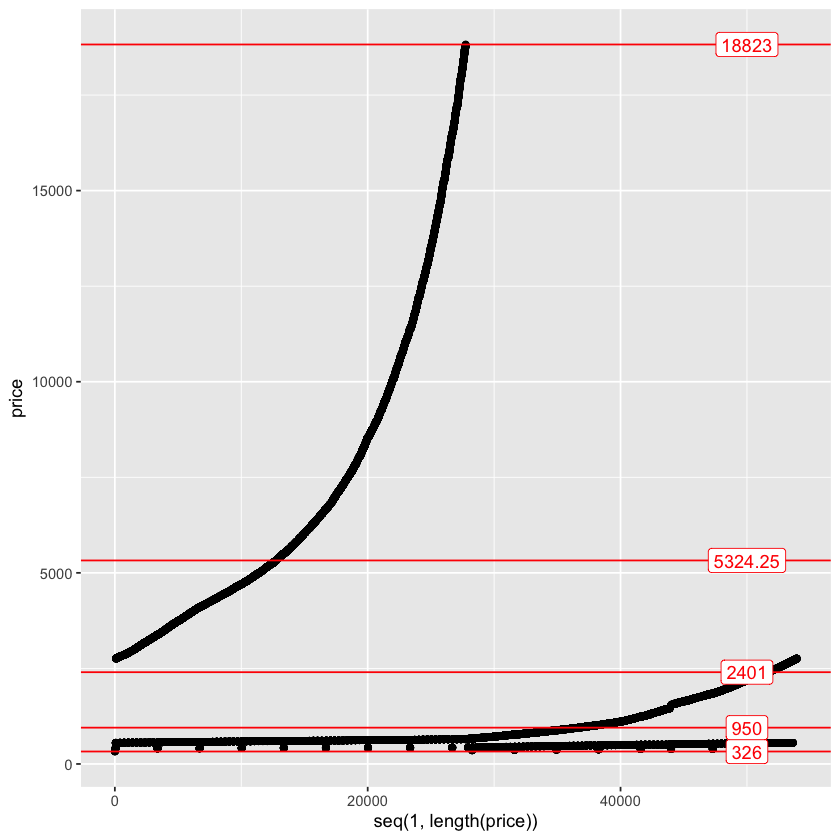

In [24]:
ggplot()+
geom_point(aes(x=seq(1, length(price)),y=price))+
geom_hline(yintercept=quantile(price),color="red")+
geom_label(aes(x=50000,y=quantile(price)),label=quantile(price),color="red")

but this data are better represented by boxplots

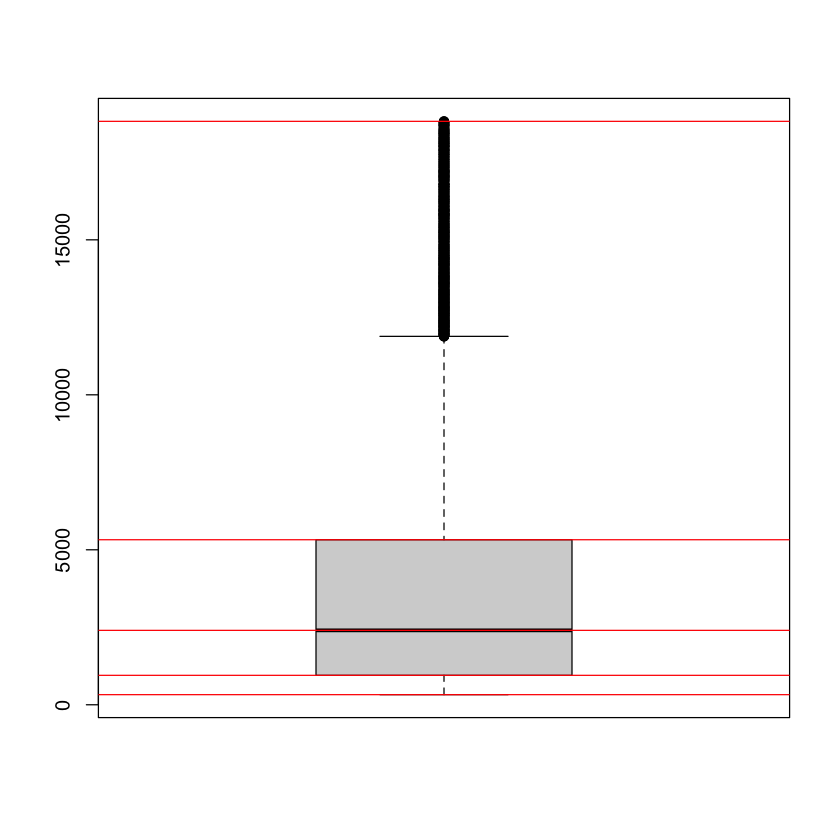

In [27]:
boxplot(price)
abline(h=quantile(price),col="red")

if u want a multi Y boxplot. use the tilde 

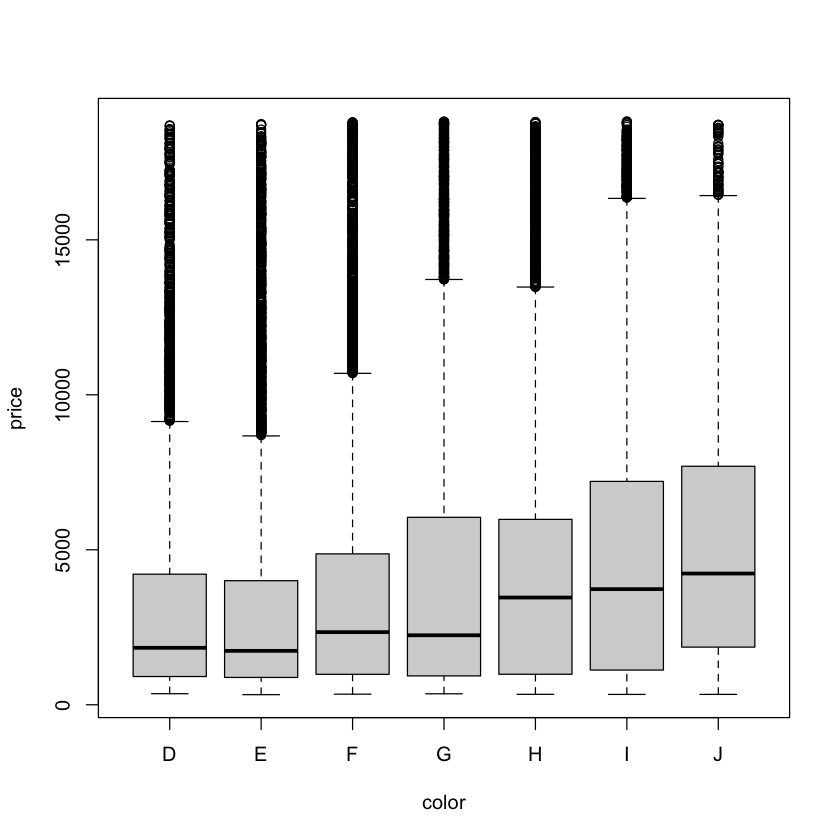

In [36]:
boxplot(price~color)

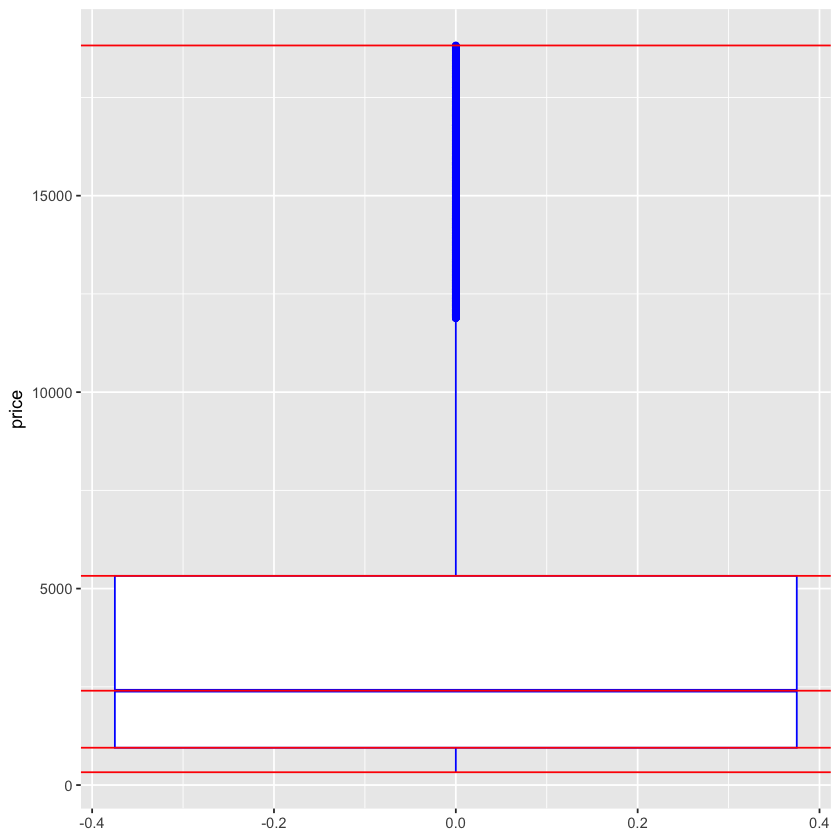

In [35]:
ggplot()+
geom_boxplot(aes(y=price), color = 'blue')+
geom_hline(yintercept=quantile(price),color="red")

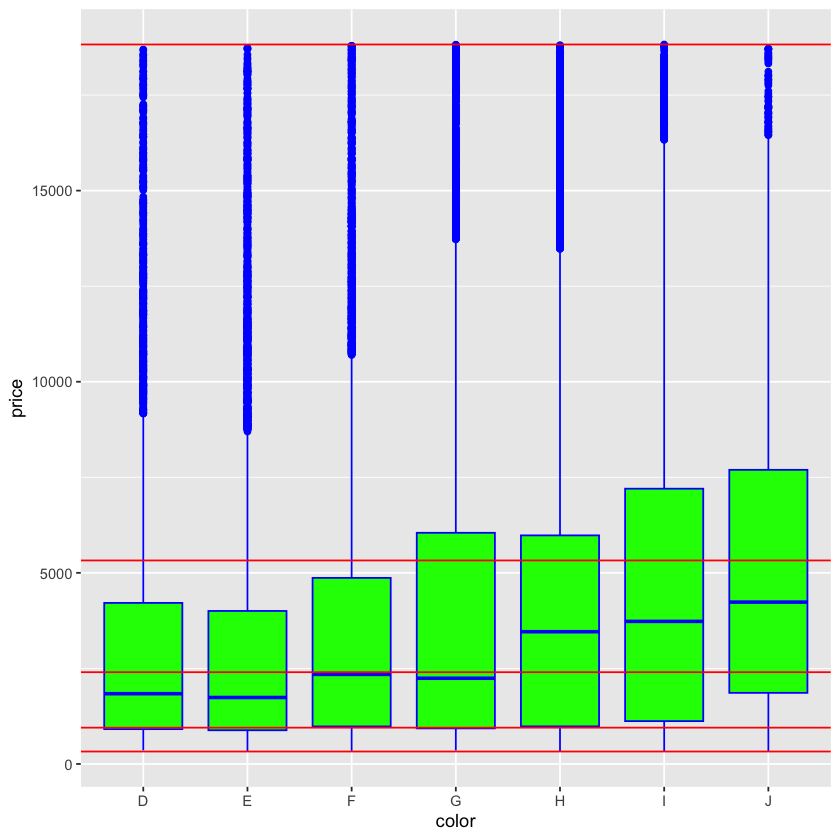

In [37]:
ggplot()+
geom_boxplot(aes(x=color, y=price), color = 'blue', fill='green')+
geom_hline(yintercept=quantile(price),color="red")

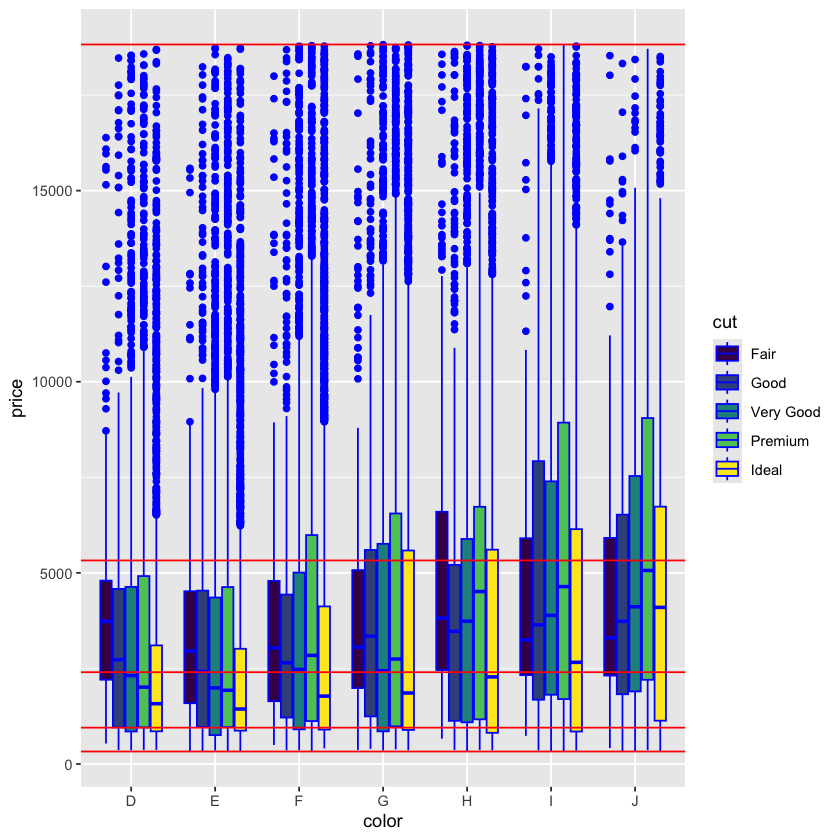

In [38]:
ggplot()+
geom_boxplot(aes(x=color, y=price, fill=cut), color = 'blue')+
geom_hline(yintercept=quantile(price),color="red")

Now let's work on the otehr indexes

In [39]:
summary(price)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    326     950    2401    3933    5324   18823 

variance

In [47]:
mean = mean(price)
n = length(price)
sigma2 = sum((price-mean)^2)/n
sigma2
sigma = sqrt(sigma2)
sigma

[1] 15915334

[1] 3989.403

In [48]:
var(price) #the variance of the price variable
sd(price) #the standard deviation of the price variable

[1] 15915629

[1] 3989.44

they are different cause by default R evaluate these indexes using n-1 and not n


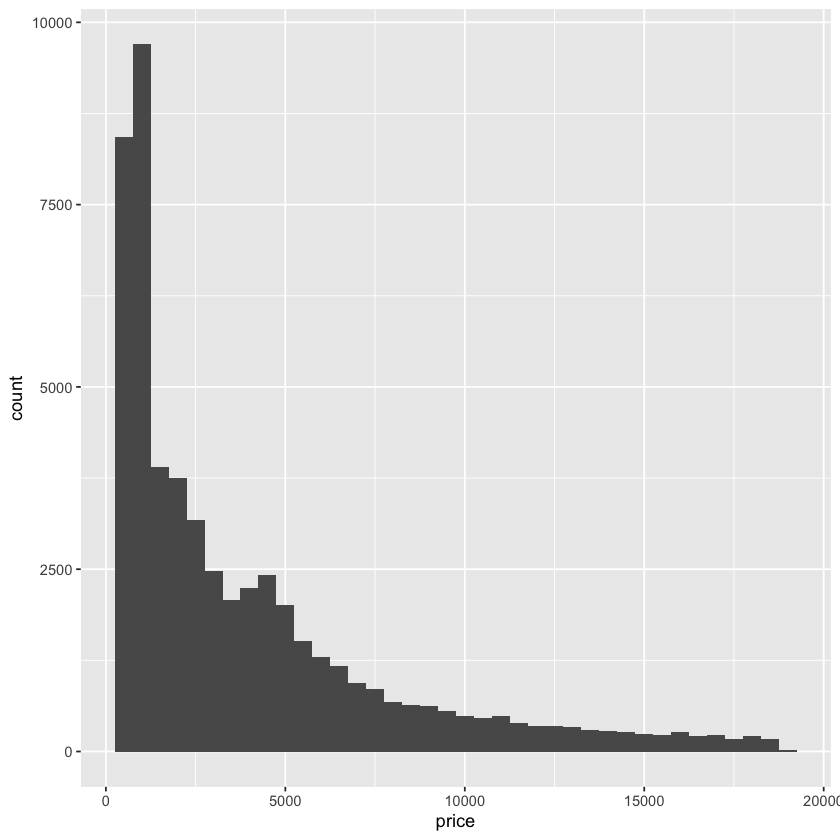

In [51]:
ggplot()+
  geom_histogram(aes(x=price),binwidth = 500)

it's not a normal distribution, or ... it follows only one brench of the normal ditrib with center value close to 0


coeff variation

In [53]:
mean(z)
sd(z)

[1] 3.538734

[1] 0.7056988

comparing price and z is not meaningful, diff measuring units and differnet values!

In [54]:
cv <- function(x){
    return(sd(x)/mean(x)*100)
}

In [55]:
cv(price)
cv(z)

[1] 101.4402

[1] 19.94213

which means that price is much more variable than z. these nubmers (from the defintion) mean that z has a stdev 20% of the average. the other 101% of the average!

what if we evaluate the variation index at the variation of a third varaible? u can do it wiht "pipes" operator!

In [58]:
# install.packages("dplyr")
library(dplyr)

also installing the dependencies ‘pkgconfig’, ‘generics’, ‘tibble’, ‘tidyselect’





The downloaded binary packages are in
	/var/folders/p3/80498z8x71z1_xfxtnstpxkc0000gn/T//Rtmpw4SIpf/downloaded_packages



Attaching package: ‘dplyr’


The following object is masked from ‘package:ggplot2’:

    vars


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [59]:
diamonds %>%
  group_by(cut) %>%
  summarise(mean_price = mean(price), sd_price = sd(price), cv_price = cv(price))

cut,mean_price,sd_price,cv_price
<ord>,<dbl>,<dbl>,<dbl>
Fair,4358.758,3560.387,81.68352
Good,3928.864,3681.590,93.70620
Very Good,3981.760,3935.862,98.84730
Premium,4584.258,4349.205,94.87261
Ideal,3457.542,3808.401,110.14765


which is a table-verion of the box plot ... if u think about it!

final one. GINI

In [63]:
giniindex <- function(x){
    ni = table(x)
    fi=ni/length(x)
    fi2 = fi^2
    J = length(table(x))

    gini <- 1/sum(fi2)
    gini.normalized <- gini/((J-1)/J)
    return(gini.normalized)
}

In [64]:
table(color)

color
    D     E     F     G     H     I     J 
 6775  9797  9542 11292  8304  5422  2808 

In [65]:
giniindex(color)

[1] 7.273598